In [ ]:
from statsbombpy import sb
import pyarrow.dataset as ds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Introduction

The goal of this notebook is to find what maximal error is acceptable. This is done by looking at the Euros 2020 data set that is openly available.
<br><br>
This data is used to obtain the action ratings by the Expected Threat model. The xT values are then distorded by adding noise with a maximal error. The maximal error for which less than 10% of all in-game players changes a quartile is found.

## Calculate player minutes per position

### Extract lineups from sb

In [2]:
# Liguea 1 has competition_id = 7
competition_id = 7
# Season 2015/2016 has season_id = 27
season_id = 27

# Get the matches for Ligue 1 2015/2016
Ligue_1_season_1516 = sb.matches(competition_id=competition_id, season_id=season_id)

In [6]:
def timestamp_to_minutes(timestamp: str, format = "hh:mm:ss") -> float:
    if timestamp is None:
        return None
    elif format == "hh:mm:ss":
        hh, mm, ss = timestamp.split(':')
        return int(hh) * 60 + int(mm) + float(ss) / 60
    elif format == "mm:ss":
        mm, ss = timestamp.split(':')
        return int(mm) + float(ss) / 60

In [8]:
time_played_per_position = {}

for match_id in tqdm(Ligue_1_season_1516['match_id'].tolist()):
    # Get the length of both halves
    raw_events = sb.events(match_id=match_id)
    half_ends = raw_events[raw_events['type'] == 'Half End'].sort_values(['period', 'timestamp'])
    half_1_length_minutes = timestamp_to_minutes(half_ends.iloc[0]['timestamp'], format="hh:mm:ss")
    half_2_length_minutes = timestamp_to_minutes(half_ends.iloc[-1]['timestamp'], format="hh:mm:ss")

    # Get the lineups
    lineups_dict = sb.lineups(match_id)
    lineups = [lineups_dict[key] for key in lineups_dict.keys()]

    # Iterate over the lineups
    for lineup in lineups:
        for idx, player in lineup.iterrows():

            # Get player ID
            player_id = player['player_id']
            
            # Iterate over the positions played by the player
            for position_data in player['positions']:
                # Get position and time data
                position = position_data['position']
                start_minute = timestamp_to_minutes(position_data['from'], format="mm:ss")
                end_minute = timestamp_to_minutes(position_data['to'], format="mm:ss")
                start_period = position_data['from_period']
                end_period = position_data['to_period']

                # If playing till the end of the match, None is given, so set to half 2 length
                if end_minute is None and end_period is None:
                    end_period = 2
                    end_minute = half_2_length_minutes + 45

                # Calculate minutes played based on periods
                if start_period == 1 and end_period == 1:
                    minutes_played = end_minute - start_minute
                elif start_period == 1 and end_period == 2:
                    # Minutes played is minutes first half + minutes second half
                    # Note: start of 2nd half is not consistend between the two formats
                    minutes_played = (half_1_length_minutes - start_minute) + (end_minute - 45)

                elif start_period == 2 and end_period == 2:
                    minutes_played = end_minute - start_minute
                else:
                    print(f"Player ID: {player_id}, Position: {position} in match {match_id} had unexpected period values:")
                    print(f"starting from period {start_period} timestamp {start_minute}, ending at period {end_period} timestamp {end_minute}")
                    # raise ValueError("Unexpected period values")
                
                # Accumulate time played per position
                time_played = end_minute - start_minute
                if (player_id, position) not in time_played_per_position:
                    time_played_per_position[(player_id, position)] = time_played
                else:
                    time_played_per_position[(player_id, position)] += time_played        


 40%|███▉      | 149/377 [02:24<04:33,  1.20s/it]

Player ID: 3230, Position: Center Forward in match 3829416 had unexpected period values:
starting from period 2 timestamp 45.05, ending at period 1 timestamp 46.083333333333336
Player ID: 16462, Position: Right Wing Back in match 3829416 had unexpected period values:
starting from period 2 timestamp 45.05, ending at period 1 timestamp 46.083333333333336


100%|██████████| 377/377 [07:04<00:00,  1.13s/it]


In [9]:
# Convert to DataFrame for easier analysis
df_time_played = pd.DataFrame.from_dict(time_played_per_position, orient='index', columns=['minutes_played'])
df_time_played.index = pd.MultiIndex.from_tuples(df_time_played.index, names=['player_id', 'position'])
df_time_played = df_time_played.reset_index()
df_time_played

,player_id,position,minutes_played
0,2969,Right Midfield,294.618700
1,3002,Right Center Midfield,746.740150
2,3002,Center Attacking Midfield,939.821900
3,3161,Left Midfield,165.475583
4,4390,Left Back,470.167617
...,...,...,...
3048,7428,Right Center Back,95.074083
3049,3292,Left Wing,3.650000
3050,4417,Left Wing Back,0.166667
3051,4417,Center Forward,21.567517


In [10]:
df_time_played.value_counts('position')

position
Center Attacking Midfield    246
Right Wing                   224
Left Wing                    218
Left Center Midfield         193
Right Center Midfield        192
Center Forward               181
Left Midfield                176
Right Midfield               173
Right Defensive Midfield     165
Left Defensive Midfield      161
Right Center Forward         141
Right Back                   134
Center Defensive Midfield    131
Left Center Forward          131
Right Center Back            130
Left Center Back             121
Left Back                    116
Right Wing Back               51
Left Wing Back                51
Goalkeeper                    46
Center Back                   32
Right Attacking Midfield      21
Left Attacking Midfield       19
Name: count, dtype: int64

In [11]:
df_time_played[df_time_played['minutes_played'] >= 300].value_counts('position')

position
Right Center Back            57
Right Back                   51
Left Back                    51
Left Center Back             49
Center Forward               47
Right Wing                   39
Right Defensive Midfield     38
Goalkeeper                   35
Left Defensive Midfield      35
Left Wing                    35
Center Attacking Midfield    31
Center Defensive Midfield    30
Right Center Midfield        27
Left Center Midfield         26
Left Midfield                22
Right Midfield               20
Left Center Forward          18
Right Center Forward         17
Left Wing Back                4
Center Back                   3
Left Attacking Midfield       2
Right Wing Back               2
Right Attacking Midfield      1
Name: count, dtype: int64

## Filter on position

In [12]:
# Give position to filter on
position_filter = 'Center Forward'

In [13]:
df_time_played ['position'].value_counts()

position
Center Attacking Midfield    246
Right Wing                   224
Left Wing                    218
Left Center Midfield         193
Right Center Midfield        192
Center Forward               181
Left Midfield                176
Right Midfield               173
Right Defensive Midfield     165
Left Defensive Midfield      161
Right Center Forward         141
Right Back                   134
Center Defensive Midfield    131
Left Center Forward          131
Right Center Back            130
Left Center Back             121
Left Back                    116
Right Wing Back               51
Left Wing Back                51
Goalkeeper                    46
Center Back                   32
Right Attacking Midfield      21
Left Attacking Midfield       19
Name: count, dtype: int64

In [14]:
df_time_played[df_time_played['minutes_played'] >= 300].value_counts('position')

position
Right Center Back            57
Right Back                   51
Left Back                    51
Left Center Back             49
Center Forward               47
Right Wing                   39
Right Defensive Midfield     38
Goalkeeper                   35
Left Defensive Midfield      35
Left Wing                    35
Center Attacking Midfield    31
Center Defensive Midfield    30
Right Center Midfield        27
Left Center Midfield         26
Left Midfield                22
Right Midfield               20
Left Center Forward          18
Right Center Forward         17
Left Wing Back                4
Center Back                   3
Left Attacking Midfield       2
Right Wing Back               2
Right Attacking Midfield      1
Name: count, dtype: int64

Number of players plaing as Center Forward: 181
Average minutes played for Center Forward: 284.30974116022094
Number of Center Forward with more than 300 minutes played: 47


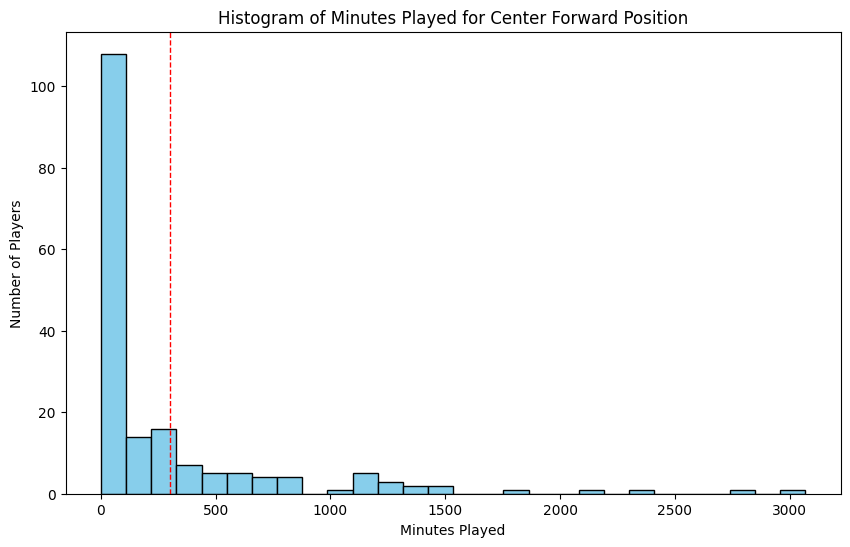

In [15]:
# Histogram of minutes played per for right winger position
df_pos = df_time_played[df_time_played['position'] == position_filter]
# df_pos = df_time_played[df_time_played['position'] == 'Center Attacking Midfield']
# df_pos = df_time_played[df_time_played['position'].isin(position_filter_list)]
print(f"Number of players plaing as {position_filter}: {len(df_pos)}")
print(f"Average minutes played for {position_filter}: {df_pos['minutes_played'].mean()}")
print(f"Number of {position_filter} with more than 300 minutes played: {len(df_pos[df_pos['minutes_played'] > 300])}")
plt.figure(figsize=(10,6))
plt.hist(df_pos['minutes_played'], bins='auto', color='skyblue', edgecolor='black')
plt.axvline(300, color='red', linestyle='dashed', linewidth=1)
plt.title(f'Histogram of Minutes Played for {position_filter} Position')
plt.xlabel('Minutes Played')
plt.ylabel('Number of Players')
plt.show()

In [16]:
selected_player_ids = df_pos[df_pos['minutes_played'] > 300]['player_id'].tolist()
n_players = len(selected_player_ids)
print(f"Number of players with more than 300 minutes played as {position_filter}: {n_players}")

Number of players with more than 300 minutes played as Center Forward: 47


## Prepare xT created values

In [ ]:
dataset = ds.dataset(
    "../../../data-storage/outputs/maximal-error/player_resampled_xT_ratings.parquet.parquet",
    format="parquet"
)

# Build filters
filter_expr = (
    (ds.field("position") == position_filter) &
    (ds.field("player_id").isin(selected_player_ids))
)

# Scan only matching rows
table = dataset.to_table(
    filter=filter_expr,
    columns=None  # or specify needed columns
)

df_xT_pos = table.to_pandas()
df_xT_pos.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6110047 entries, 0 to 6110046
Data columns (total 11 columns):
 #   Column            Dtype  
---  ------            -----  
 0   player_id         float64
 1   position          object 
 2   xT_sum_true       float64
 3   n_actions         int64  
 4   n_x               int64  
 5   n_y               int64  
 6   model_type        object 
 7   xT_sum_resampled  float64
 8   sample_size       float64
 9   i_bootstrap       float64
 10  random_state      float64
dtypes: float64(6), int64(3), object(2)
memory usage: 1.1 GB


In [19]:
# Split the true values and resampled values
df_xT_pos_true = df_xT_pos[df_xT_pos['xT_sum_true'].notnull()].copy()
df_xT_pos_resampled = df_xT_pos[df_xT_pos['xT_sum_true'].isnull()].copy()
del df_xT_pos  # free memory

print(f"Shape of true xT values: {df_xT_pos_true.shape}")
print(f"Shape of resampled xT values: {df_xT_pos_resampled.shape[0]:,}")

Shape of true xT values: (47, 11)
Shape of resampled xT values: 6,110,000


In [20]:
# Calculate the sum of xT created per player
xT_per_player_resampled = df_xT_pos_resampled.groupby(['player_id', 'position', 'n_x', 'n_y', 'sample_size', 'i_bootstrap'])['xT_sum_resampled'].sum().reset_index()

# Merge the playing time to the xT created
xT_per_player_resampled = xT_per_player_resampled.merge(
    df_time_played,
    on=['player_id', 'position'],
    how='left'
)

# Calculate xT added per 90 minutes
xT_per_player_resampled['xT_created_per90_resampled'] = (xT_per_player_resampled['xT_sum_resampled'] / xT_per_player_resampled['minutes_played']) * 90
xT_per_player_resampled.describe()


,player_id,n_x,n_y,sample_size,i_bootstrap,xT_sum_resampled,minutes_played,xT_created_per90_resampled
count,6.110000e+06,6110000.0,6110000.0,6.110000e+06,6.110000e+06,6.110000e+06,6.110000e+06,6.110000e+06
mean,3.356970e+04,16.0,12.0,1.333846e+06,4.999500e+03,1.174197e+00,9.385894e+02,1.035677e-01
std,9.637911e+04,0.0,0.0,1.337141e+06,2.886752e+03,1.351659e+00,6.425976e+02,4.990033e-02
min,3.010000e+03,16.0,12.0,1.000000e+05,0.000000e+00,5.985731e-02,3.134518e+02,1.520806e-02
25%,3.451000e+03,16.0,12.0,2.400000e+05,2.499750e+03,4.501793e-01,4.657203e+02,7.171223e-02
50%,4.909000e+03,16.0,12.0,6.300000e+05,4.999500e+03,7.384464e-01,7.232129e+02,9.352963e-02
75%,1.568900e+04,16.0,12.0,2.000000e+06,7.499250e+03,1.070900e+00,1.275858e+03,1.190471e-01
max,4.015410e+05,16.0,12.0,4.000000e+06,9.999000e+03,9.469661e+00,3.069068e+03,3.547565e-01


In [21]:
df_xT_pos_true

,player_id,position,xT_sum_true,n_actions,n_x,n_y,model_type,xT_sum_resampled,sample_size,i_bootstrap,random_state
0,3010.0,Center Forward,2.927790,172,16,12,true,NaN,NaN,NaN,NaN
1,3018.0,Center Forward,2.498337,234,16,12,true,NaN,NaN,NaN,NaN
2,3020.0,Center Forward,0.253696,34,16,12,true,NaN,NaN,NaN,NaN
3,3038.0,Center Forward,5.720818,445,16,12,true,NaN,NaN,NaN,NaN
4,3111.0,Center Forward,0.466363,73,16,12,true,NaN,NaN,NaN,NaN
5,3114.0,Center Forward,2.081371,200,16,12,true,NaN,NaN,NaN,NaN
6,3179.0,Center Forward,0.725388,106,16,12,true,NaN,NaN,NaN,NaN
7,3184.0,Center Forward,0.939429,125,16,12,true,NaN,NaN,NaN,NaN
8,3246.0,Center Forward,0.521501,151,16,12,true,NaN,NaN,NaN,NaN
9,3357.0,Center Forward,0.253726,25,16,12,true,NaN,NaN,NaN,NaN


In [22]:
# Calculate the sum of xT created per player
xT_per_player_true = df_xT_pos_true.groupby(['player_id', 'position', 'n_x', 'n_y'])['xT_sum_true'].sum().reset_index()

# Merge the playing time to the xT created
xT_per_player_true = xT_per_player_true.merge(
    df_time_played,
    on=['player_id', 'position'],
    how='left'
)

# Calculate xT added per 90 minutes
xT_per_player_true['xT_created_per90_true'] = (xT_per_player_true['xT_sum_true'] / xT_per_player_true['minutes_played']) * 90
xT_per_player_true.describe()

,player_id,n_x,n_y,xT_sum_true,minutes_played,xT_created_per90_true
count,47.000000,47.0,47.0,47.000000,47.000000,47.000000
mean,33569.702128,16.0,12.0,1.164110,938.589380,0.102664
std,97421.073063,0.0,0.0,1.356306,649.544775,0.049885
min,3010.000000,16.0,12.0,0.167012,313.451817,0.031891
25%,3454.000000,16.0,12.0,0.445578,467.197542,0.071578
50%,4909.000000,16.0,12.0,0.725388,723.212883,0.093548
75%,13009.500000,16.0,12.0,1.040414,1229.150542,0.116893
max,401541.000000,16.0,12.0,7.136372,3069.067633,0.267346


In [23]:
xT_per_player_true

,player_id,position,n_x,n_y,xT_sum_true,minutes_played,xT_created_per90_true
0,3010.0,Center Forward,16,12,2.927790,1408.648833,0.187059
1,3018.0,Center Forward,16,12,2.498337,2099.285650,0.107108
2,3020.0,Center Forward,16,12,0.253696,313.451817,0.072843
3,3038.0,Center Forward,16,12,5.720818,3069.067633,0.167762
4,3111.0,Center Forward,16,12,0.466363,542.300000,0.077398
5,3114.0,Center Forward,16,12,2.081371,1395.452717,0.134238
6,3179.0,Center Forward,16,12,0.725388,1139.646283,0.057285
7,3184.0,Center Forward,16,12,0.939429,1275.857883,0.066268
8,3246.0,Center Forward,16,12,0.521501,1471.755817,0.031891
9,3357.0,Center Forward,16,12,0.253726,324.765250,0.070313


In [24]:
# Calculate the quartile of each player per model configuration
xT_per_player_resampled['xT_created_per90_quartile_resampled'] = xT_per_player_resampled.groupby(
    ['n_x', 'n_y', 'sample_size', 'i_bootstrap']
)['xT_created_per90_resampled'].transform(
    lambda x: pd.qcut(x, 4, labels=False, duplicates='drop') + 1
)

xT_per_player_true['xT_created_per90_quartile_true'] = xT_per_player_true.groupby(
    ['n_x', 'n_y']
)['xT_created_per90_true'].transform(
    lambda x: pd.qcut(x, 4, labels=False, duplicates='drop') + 1
)

xT_per_player_resampled

,player_id,position,n_x,n_y,sample_size,i_bootstrap,xT_sum_resampled,minutes_played,xT_created_per90_resampled,xT_created_per90_quartile_resampled
0,3010.0,Center Forward,16,12,100000.0,0.0,3.024904,1408.648833,0.193264,4
1,3010.0,Center Forward,16,12,100000.0,1.0,2.991089,1408.648833,0.191104,4
2,3010.0,Center Forward,16,12,100000.0,2.0,2.758320,1408.648833,0.176232,4
3,3010.0,Center Forward,16,12,100000.0,3.0,3.361428,1408.648833,0.214765,4
4,3010.0,Center Forward,16,12,100000.0,4.0,2.932516,1408.648833,0.187361,4
...,...,...,...,...,...,...,...,...,...,...
6109995,401541.0,Center Forward,16,12,4000000.0,9995.0,0.870521,1293.474233,0.060571,1
6109996,401541.0,Center Forward,16,12,4000000.0,9996.0,0.857624,1293.474233,0.059674,1
6109997,401541.0,Center Forward,16,12,4000000.0,9997.0,0.886199,1293.474233,0.061662,1
6109998,401541.0,Center Forward,16,12,4000000.0,9998.0,0.852783,1293.474233,0.059337,1


In [ ]:
# Calculate the differences between resampled an true values
xT_merged = xT_per_player_resampled.merge(
    xT_per_player_true[['player_id', 'n_x', 'n_y', 'xT_created_per90_true', 'xT_created_per90_quartile_true']],
    on=['player_id', 'n_x', 'n_y'],
    how='left',
)
xT_merged['quartile_changes'] = np.abs(xT_merged['xT_created_per90_quartile_resampled'] - xT_merged['xT_created_per90_quartile_true'])
xT_merged['incorrect_estimation'] = (xT_merged['xT_created_per90_quartile_resampled'] != xT_merged['xT_created_per90_quartile_true'])
xT_merged

,player_id,position,n_x,n_y,sample_size,i_bootstrap,xT_sum_resampled,minutes_played,xT_created_per90_resampled,xT_created_per90_quartile_resampled,xT_created_per90_true,xT_created_per90_quartile_true,quartile_changes,incorrect_estimation
0,3010.0,Center Forward,16,12,100000.0,0.0,3.024904,1408.648833,0.193264,4,0.187059,4,0,False
1,3010.0,Center Forward,16,12,100000.0,1.0,2.991089,1408.648833,0.191104,4,0.187059,4,0,False
2,3010.0,Center Forward,16,12,100000.0,2.0,2.758320,1408.648833,0.176232,4,0.187059,4,0,False
3,3010.0,Center Forward,16,12,100000.0,3.0,3.361428,1408.648833,0.214765,4,0.187059,4,0,False
4,3010.0,Center Forward,16,12,100000.0,4.0,2.932516,1408.648833,0.187361,4,0.187059,4,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6109995,401541.0,Center Forward,16,12,4000000.0,9995.0,0.870521,1293.474233,0.060571,1,0.060179,1,0,False
6109996,401541.0,Center Forward,16,12,4000000.0,9996.0,0.857624,1293.474233,0.059674,1,0.060179,1,0,False
6109997,401541.0,Center Forward,16,12,4000000.0,9997.0,0.886199,1293.474233,0.061662,1,0.060179,1,0,False
6109998,401541.0,Center Forward,16,12,4000000.0,9998.0,0.852783,1293.474233,0.059337,1,0.060179,1,0,False


## Add the model error info

In [ ]:
# Load both old and new error dataframes
df_errors = pd.read_csv('../../../data-storage/outputs/maximal-error/bootstrap_errors.csv').rename(columns={'sample_size': 'N'})
print(df_errors.shape)

# Filter on the 16x12 grid
df_errors = df_errors[(df_errors['n_x'] == 16) & (df_errors['n_y'] == 12)].copy()

df_errors = df_errors[['n_x', 'n_y', 'N', 'i_bootstrap', 'random_state', 'xT_error_inf_norm']].rename(columns={'N': 'sample_size'})
df_errors.head()

(130000, 21)


,n_x,n_y,sample_size,i_bootstrap,random_state,xT_error_inf_norm
0,16,12,4000000,0,15760042,0.017879
1,16,12,4000000,1,15760043,0.009632
2,16,12,4000000,2,15760044,0.007746
3,16,12,4000000,3,15760045,0.016141
4,16,12,4000000,4,15760046,0.008392


In [32]:
xT_merged = xT_merged.merge(
    df_errors,
    on=['n_x', 'n_y', 'sample_size', 'i_bootstrap'],
    how='left'
)
xT_merged

,player_id,position,n_x,n_y,sample_size,i_bootstrap,xT_sum_resampled,minutes_played,xT_created_per90_resampled,xT_created_per90_quartile_resampled,xT_created_per90_true,xT_created_per90_quartile_true,quartile_changes,incorrect_estimation,random_state,xT_error_inf_norm
0,3010.0,Center Forward,16,12,100000.0,0.0,3.024904,1408.648833,0.193264,4,0.187059,4,0,False,11860042,0.056519
1,3010.0,Center Forward,16,12,100000.0,1.0,2.991089,1408.648833,0.191104,4,0.187059,4,0,False,11860043,0.025715
2,3010.0,Center Forward,16,12,100000.0,2.0,2.758320,1408.648833,0.176232,4,0.187059,4,0,False,11860044,0.075247
3,3010.0,Center Forward,16,12,100000.0,3.0,3.361428,1408.648833,0.214765,4,0.187059,4,0,False,11860045,0.088615
4,3010.0,Center Forward,16,12,100000.0,4.0,2.932516,1408.648833,0.187361,4,0.187059,4,0,False,11860046,0.057338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6109995,401541.0,Center Forward,16,12,4000000.0,9995.0,0.870521,1293.474233,0.060571,1,0.060179,1,0,False,15770037,0.011006
6109996,401541.0,Center Forward,16,12,4000000.0,9996.0,0.857624,1293.474233,0.059674,1,0.060179,1,0,False,15770038,0.011764
6109997,401541.0,Center Forward,16,12,4000000.0,9997.0,0.886199,1293.474233,0.061662,1,0.060179,1,0,False,15770039,0.012696
6109998,401541.0,Center Forward,16,12,4000000.0,9998.0,0.852783,1293.474233,0.059337,1,0.060179,1,0,False,15770040,0.022461


# Calculate number of quantile changes per model

In [33]:
model_mistakes = xT_merged.groupby(
    ['n_x', 'n_y', 'sample_size', 'i_bootstrap']).agg(
        max_quartile_change = ('quartile_changes', 'max'),
        n_quartile_changes = ('incorrect_estimation', 'sum'),
        model_error = ('xT_error_inf_norm', 'first'),
    ).reset_index()
model_mistakes

,n_x,n_y,sample_size,i_bootstrap,max_quartile_change,n_quartile_changes,model_error
0,16,12,100000.0,0.0,1,12,0.056519
1,16,12,100000.0,1.0,1,6,0.025715
2,16,12,100000.0,2.0,1,12,0.075247
3,16,12,100000.0,3.0,1,4,0.088615
4,16,12,100000.0,4.0,1,6,0.057338
...,...,...,...,...,...,...,...
129995,16,12,4000000.0,9995.0,0,0,0.011006
129996,16,12,4000000.0,9996.0,0,0,0.011764
129997,16,12,4000000.0,9997.0,0,0,0.012696
129998,16,12,4000000.0,9998.0,0,0,0.022461


In [ ]:
model_mistakes['max_quartile_change'].value_counts()

np.int64(2)

# Investigate results

In [35]:
model_mistakes['n_quartile_changes'].value_counts()

n_quartile_changes
2     33271
0     31047
4     25245
6     19864
8     10734
10     4861
12     1659
9       836
11      665
7       599
14      486
13      294
5       214
16       88
15       70
3        32
18       19
17       12
19        2
20        2
Name: count, dtype: int64

## Inspect quartiles

In [40]:
# choose quantiles of interest
qs = [0.10, 0.25, 0.50, 0.75, 0.90]

# bin model_error (here: quantile bins)
model_mistakes['error_bin'] = pd.qcut(
    model_mistakes['model_error'],
    q=30,        # number of bins
    duplicates='drop'
)

# compute conditional quantiles
conditional_quantiles = (
    model_mistakes
    .groupby('error_bin')['n_quartile_changes']
    .quantile(qs)
    .unstack()
)
conditional_quantiles['bin_center'] = conditional_quantiles.index.categories.mid

print(conditional_quantiles)

                    0.1  0.25  0.5  0.75   0.9  bin_center
error_bin                                                 
(0.00093, 0.00703]  0.0   0.0  0.0   2.0   2.0    0.003980
(0.00703, 0.00843]  0.0   0.0  0.0   2.0   4.0    0.007730
(0.00843, 0.00954]  0.0   0.0  0.0   2.0   4.0    0.008985
(0.00954, 0.0105]   0.0   0.0  2.0   2.0   4.0    0.010020
(0.0105, 0.0116]    0.0   0.0  2.0   2.0   4.0    0.011050
(0.0116, 0.0126]    0.0   0.0  2.0   2.0   4.0    0.012100
(0.0126, 0.0136]    0.0   0.0  2.0   2.0   4.0    0.013100
(0.0136, 0.0147]    0.0   0.0  2.0   2.0   4.0    0.014150
(0.0147, 0.0159]    0.0   0.0  2.0   2.0   4.0    0.015300
(0.0159, 0.0172]    0.0   0.0  2.0   2.0   4.0    0.016550
(0.0172, 0.0186]    0.0   0.0  2.0   4.0   4.0    0.017900
(0.0186, 0.0201]    0.0   0.0  2.0   4.0   4.0    0.019350
(0.0201, 0.0218]    0.0   0.0  2.0   4.0   6.0    0.020950
(0.0218, 0.0237]    0.0   0.0  2.0   4.0   6.0    0.022750
(0.0237, 0.0257]    0.0   2.0  2.0   4.0   6.0    0.0247

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_20968\598536396.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('error_bin')['n_quartile_changes']


In [47]:
sns_palette = sns.color_palette()
line_color = sns_palette[0]
fill_color = sns_palette[0]

#### Estimate quantiles ####
# Define quartiles to plot
qs = [0.10, 0.50, 0.90]
quantile_4_threshold = 0.90
n_bins = 75

# Sort quantiles high -> low
qs_sorted = sorted(qs, reverse=True)

# bin model_error (here: quantile bins)
model_mistakes['error_bin'] = pd.qcut(
    model_mistakes['model_error'],
    q=n_bins,        
)
# print(f"Number of data points per bin:\n{model_mistakes['error_bin'].value_counts()}")

# compute conditional quantiles
conditional_quantiles = (
    model_mistakes
    .groupby('error_bin')['n_quartile_changes']
    .quantile(qs)
    .unstack()
)
conditional_quantiles['bin_center'] = conditional_quantiles.index.categories.mid


C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_20968\434248807.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('error_bin')['n_quartile_changes']


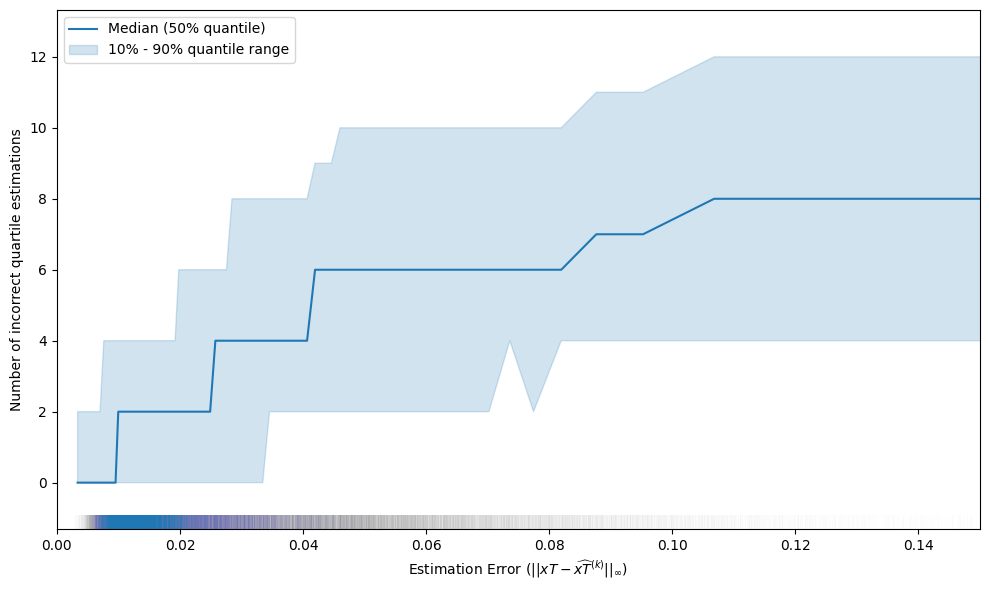

In [48]:
fig, ax_main = plt.subplots(figsize=(10, 6))

sns_palette = sns.color_palette()
line_color = sns_palette[0]
fill_color = sns_palette[0]


ax_main.plot(
    conditional_quantiles['bin_center'],
    conditional_quantiles[0.50],
    # marker='x',
    label='Median (50% quantile)',
    color=line_color,
)
ax_main.fill_between(
    conditional_quantiles['bin_center'],
    y1=conditional_quantiles[0.10],
    y2=conditional_quantiles[0.90],
    color=fill_color,
    alpha=0.2,
    label='10% - 90% quantile range',
)
ax_main.set_xlabel(r'Estimation Error ($||xT-\widehat{xT}^{(k)}||_{\infty}$)')
ax_main.set_ylabel('Number of incorrect quartile estimations')
ax_main.yaxis.set_major_locator(plt.MultipleLocator(2))
ax_main.set_xlim(0, 0.15)


sns.rugplot(
    data=model_mistakes.sample(frac=0.4, random_state=42),
    x='model_error',
    ax=ax_main,
    color=line_color,
    alpha=.002,
    height=0.03,  # fraction of the y-axis height
    linewidth=0.4,
)


plt.legend()
plt.tight_layout()
plt.show()

0.019200000000000002


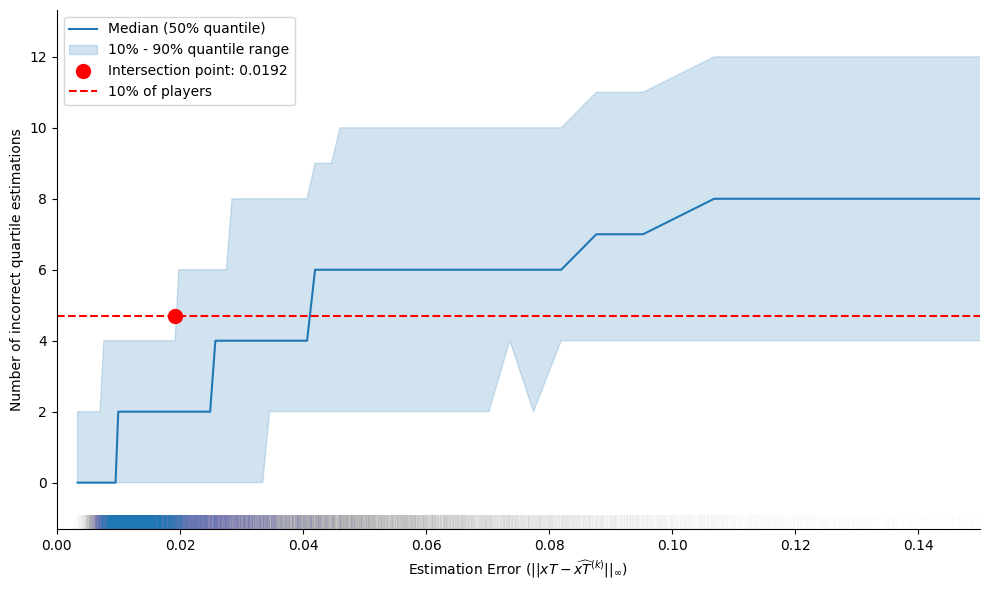

In [49]:
fig, ax_main = plt.subplots(figsize=(10, 6))

sns_palette = sns.color_palette()
line_color = sns_palette[0]
fill_color = sns_palette[0]


ax_main.plot(
    conditional_quantiles['bin_center'],
    conditional_quantiles[0.50],
    # marker='x',
    label='Median (50% quantile)',
    color=line_color,
)
ax_main.fill_between(
    conditional_quantiles['bin_center'],
    y1=conditional_quantiles[0.10],
    y2=conditional_quantiles[0.90],
    color=fill_color,
    alpha=0.2,
    label='10% - 90% quantile range',
)
ax_main.set_xlabel(r'Estimation Error ($||xT-\widehat{xT}^{(k)}||_{\infty}$)')
ax_main.set_ylabel('Number of incorrect quartile estimations')
ax_main.yaxis.set_major_locator(plt.MultipleLocator(2))
ax_main.set_xlim(0, 0.15)


sns.rugplot(
    data=model_mistakes.sample(frac=0.4, random_state=42),
    x='model_error',
    ax=ax_main,
    color=line_color,
    alpha=.002,
    height=0.03,  # fraction of the y-axis height
    linewidth=0.4,
)

ax_main.set_ylim(ax_main.get_ylim())

# First meeting marker (larger, different color)
first_meeting_10_percent = conditional_quantiles[conditional_quantiles[quantile_4_threshold] <= 0.1*n_players]['bin_center'].max()
first_meeting_10_percent_y = conditional_quantiles[conditional_quantiles[quantile_4_threshold] <= 0.1*n_players][quantile_4_threshold].max()
print(first_meeting_10_percent)
ax_main.plot(
    first_meeting_10_percent,
    n_players * 0.10,
    marker='o',
    linewidth=0,
    markersize=10,
    color='red',
    label=f'Intersection point: {first_meeting_10_percent:.4f}'
)

# Horizontal threshold line
ax_main.axhline(
    n_players * 0.10,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='10% of players'
)

ax_main.spines[['top', 'right']].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

0.019200000000000002


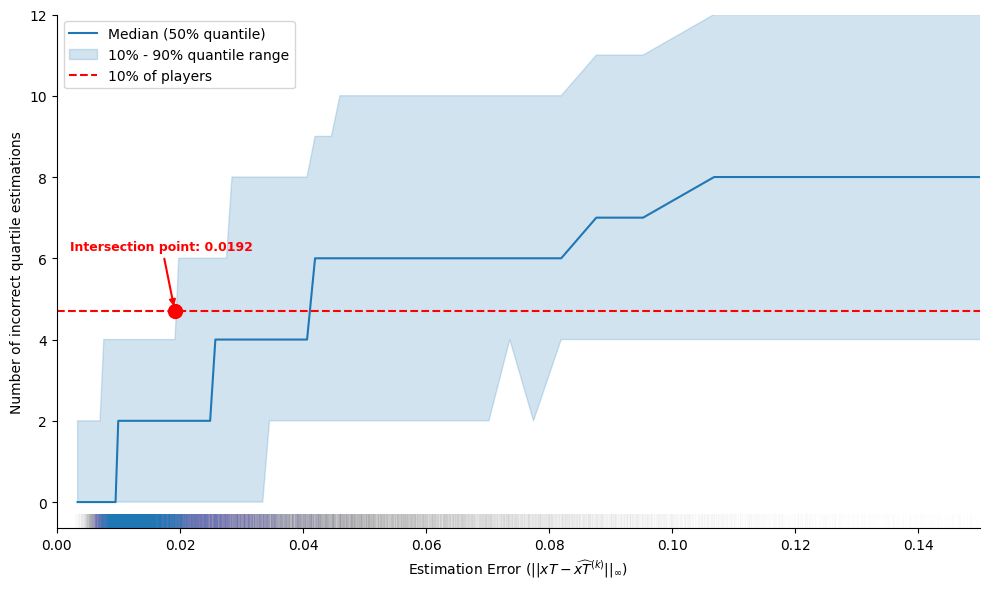

In [50]:
fig, ax_main = plt.subplots(figsize=(10, 6))

sns_palette = sns.color_palette()
line_color = sns_palette[0]
fill_color = sns_palette[0]


ax_main.plot(
    conditional_quantiles['bin_center'],
    conditional_quantiles[0.50],
    # marker='x',
    label='Median (50% quantile)',
    color=line_color,
)
ax_main.fill_between(
    conditional_quantiles['bin_center'],
    y1=conditional_quantiles[0.10],
    y2=conditional_quantiles[0.90],
    color=fill_color,
    alpha=0.2,
    label='10% - 90% quantile range',
)
ax_main.set_xlabel(r'Estimation Error ($||xT-\widehat{xT}^{(k)}||_{\infty}$)')
ax_main.set_ylabel('Number of incorrect quartile estimations')
ax_main.yaxis.set_major_locator(plt.MultipleLocator(2))
ax_main.set_xlim(0, 0.15)


sns.rugplot(
    data=model_mistakes.sample(frac=0.4, random_state=42),
    x='model_error',
    ax=ax_main,
    color=line_color,
    alpha=.002,
    height=0.03,  # fraction of the y-axis height
    linewidth=0.4,
)

ax_main.set_ylim(ax_main.get_ylim())

# First meeting marker (larger, different color)
first_meeting_10_percent = conditional_quantiles[conditional_quantiles[quantile_4_threshold] <= 0.1*n_players]['bin_center'].max()
first_meeting_10_percent_y = conditional_quantiles[conditional_quantiles[quantile_4_threshold] <= 0.1*n_players][quantile_4_threshold].max()
print(first_meeting_10_percent)
ax_main.plot(
    first_meeting_10_percent,
    n_players * 0.10,
    marker='o',
    linewidth=0,
    markersize=10,
    color='red',
    # label=f'Intersection point: {first_meeting_10_percent:.4f}'
    label='_nolegend_',
)

ax_main.annotate(
    f'Intersection point: {first_meeting_10_percent:.4f}',
    xy=(first_meeting_10_percent-0.0001, n_players * 0.10 + 0.05),
    xytext=(first_meeting_10_percent - 0.017, n_players * 0.10 + 1.5),
    arrowprops=dict(arrowstyle='-|>',edgecolor='red', facecolor='red', linewidth=1.5),
    fontsize=9,
    color='red',
    fontweight='bold',
)

# Horizontal threshold line
ax_main.axhline(
    n_players * 0.10,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='10% of players'
)

ax_main.spines[['top', 'right']].set_visible(False)
ax_main.set_ylim(-0.65, 12)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()